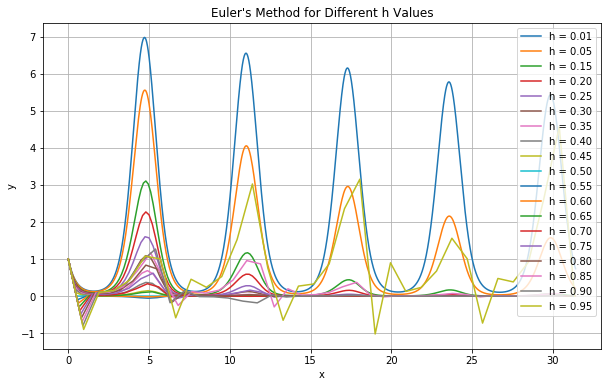

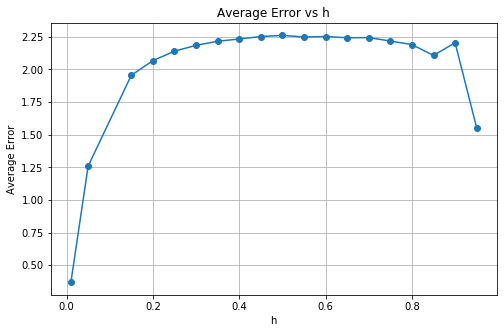

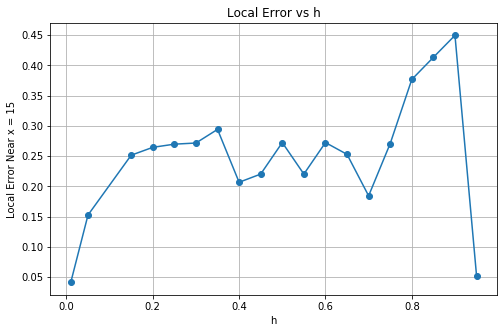

h	Average y	Average error	 y near x=15
0.01	1.910827	0.368593	0.231440
0.05	1.018602	1.259614	0.119869
0.15	0.320505	1.955839	0.020921
0.20	0.204568	2.067651	0.007903
0.25	0.136335	2.140288	0.002662
0.30	0.091602	2.185167	0.000753
0.35	0.061013	2.215906	0.000170
0.40	0.039514	2.233876	0.000018
0.45	0.024970	2.252260	0.000001
0.50	0.015873	2.261520	-0.000000
0.55	0.011968	2.249053	0.000000
0.60	0.013873	2.252663	-0.000000
0.65	0.021701	2.243102	0.000016
0.70	0.033776	2.244302	0.000005
0.75	0.060223	2.218037	0.001574
0.80	0.068476	2.191062	0.001268
0.85	0.172581	2.107630	0.038863
0.90	0.073782	2.205192	0.002522
0.95	0.789850	1.552940	0.326151


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# dy/dx = -2y*cos(x), y(0) = 1
def f(x, y):
    return -2 * y * np.cos(x)

# exact solution for error comparison
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# one Euler run
def euler_method(h, x_start=0, x_end=10*np.pi, y0=1):
    num_steps = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_start + num_steps * h, num_steps + 1)
    y = np.zeros(num_steps + 1)
    y[0] = y0

    for i in range(num_steps):
        y[i + 1] = y[i] + h * f(x[i], y[i])

    return x, y

# h values from slideshow
h_values = [0.01, 0.05] + list(np.arange(0.15, 1.0, 0.05))

avg_y_values = []
avg_errors = []
local_errors = []
y_near_15_values = []

# plot 1: Euler curves for each h
plt.figure(figsize=(10, 6))

for h in h_values:
    x, y = euler_method(h)
    y_true = y_exact(x)

    avg_y = np.mean(y)
    avg_error = np.mean(np.abs(y - y_true))

    idx_15 = np.argmin(np.abs(x - 15))
    x_near_15 = x[idx_15]
    y_near_15 = y[idx_15]
    local_error_15 = abs(y_near_15 - y_exact(x_near_15))

    avg_y_values.append(avg_y)
    avg_errors.append(avg_error)
    y_near_15_values.append(y_near_15)
    local_errors.append(local_error_15)

    plt.plot(x, y, label=f"h = {h:.2f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for Different h Values")
plt.legend()
plt.grid(True)
plt.show()

# plot 2: average error vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel("h")
plt.ylabel("Average Error")
plt.title("Average Error vs h")
plt.grid(True)
plt.show()

# plot 3: local error near x = 15 vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, local_errors, marker='o')
plt.xlabel("h")
plt.ylabel("Local Error Near x = 15")
plt.title("Local Error vs h")
plt.grid(True)
plt.show()

# print results
print("h\tAverage y\tAverage error\t y near x=15")
for i in range(len(h_values)):
    print(f"{h_values[i]:.2f}\t{avg_y_values[i]:.6f}\t{avg_errors[i]:.6f}\t{y_near_15_values[i]:.6f}")
    
# *** AI Used to cleanly format code, including improvements on plots***

## Write-up
    Smaller h gives more accurate results, while larger h increases error. The Euler curves show that big step sizes drift away from the true solution. Both average and local error increase as h increases, matching that Euler’s Method becomes less accurate with larger steps.